# Análisis de atención — BETO + LoRA

Visualización de qué tokens recibe más atención el modelo final al
clasificar ejemplos del test set.

In [ ]:
!git clone https://github.com/camistrika/BETO_HUMOR.git
%cd BETO_HUMOR
!pip install -e . -q

In [ ]:
!pip install -q torchao --upgrade
!pip install -q transformers peft datasets scikit-learn pyyaml

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel

from betohumor.config import DataConfig, BetoConfig
from betohumor.utils import set_seed
from betohumor.dataset import load_and_split

/opt/miniconda3/envs/AP_FINAL/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar el modelo final LoRA

In [3]:
LORA_PATH = '../results/lora/final_lora'

data_config = DataConfig(data_path= "../data/raw/haha_2019_train.csv")
beto_config = BetoConfig()
set_seed(data_config.seed)

df_train, df_val, df_test = load_and_split(data_config)
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)

base_model = AutoModelForSequenceClassification.from_pretrained(
    beto_config.base_model, num_labels=beto_config.num_labels,
)
model = PeftModel.from_pretrained(base_model, LORA_PATH)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Train: 19197 | Val: 2397 | Test: 2400


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 63447.58it/s]
BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECT

PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): BertForSequenceClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(31002, 768, padding_idx=1)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSelfAttention(
                  (query): lora.Linear(
                    (base_layer): Linear(in_features=768, out_features=768, bias=True)
                    (lora_dropout): ModuleDict(
                      (default): Dropout(p=0.1, inplace=False)
                    )
                    (lora_A): ModuleDict(
                      (

## 2. Función para extraer atención de un texto

Como el modelo es `PeftModel` (LoRA encima de BETO), hay que acceder al
modelo base para poder pedir `output_attentions=True`.

In [22]:
def get_attention(text, tokenizer, model, data_config, device):
    inputs = tokenizer(
        text,
        return_tensors='pt',
        max_length=data_config.max_length,
        truncation=True,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    inner_model = model.base_model.model if hasattr(model, 'base_model') else model

    # sdpa (la implementación default de atención) no expone los pesos de
    # atención; hay que forzar 'eager' para poder pedir output_attentions.
    inner_model.config._attn_implementation = "eager"
    inner_model.config.output_attentions = True

    with torch.no_grad():
        outputs = inner_model(**inputs, output_attentions=True)

    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    attentions = [att.squeeze(0).cpu() for att in outputs.attentions]
    return tokens, attentions

## 3. Token importance desde [CLS]
Promedio de atención que cada token recibe desde [CLS], en la última capa,
promediando todas las cabezas.

In [5]:
def get_cls_importance(attentions, layer=-1):
    attn_layer = attentions[layer]            # [num_heads, seq_len, seq_len]
    cls_attn = attn_layer[:, 0, :]             # atención desde el token [CLS] (posición 0)
    importance = cls_attn.mean(dim=0).numpy()  # promedio entre cabezas
    return importance

def plot_token_importance(tokens, importance, title=''):
    norm = importance / importance.max()
    order = np.argsort(norm)
    fig, ax = plt.subplots(figsize=(7, max(4, len(tokens) * 0.3)))
    ax.barh([tokens[i] for i in order], norm[order], color='#4C72B0')
    ax.set_xlabel('Importancia normalizada (atención desde [CLS])')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig

## 4. Seleccionar ejemplos representativos
Algunos de humor, algunos de no-humor.

In [10]:
from pprint import pprint
ejemplos_humor    = df_test[df_test[data_config.label_col] == 1].sample(3, random_state=data_config.seed)
ejemplos_no_humor = df_test[df_test[data_config.label_col] == 0].sample(3, random_state=data_config.seed)

ejemplos = pd.concat([ejemplos_humor, ejemplos_no_humor])
ejemplos[[data_config.text_col, data_config.label_col]]

ejemplos[data_config.text_col]
pprint([ (txt,label) for txt,label in zip(ejemplos[data_config.text_col], ejemplos[data_config.label_col])])


[('Dr al paciente: -Tras todos los estudios creo que te voy a tener que hacer '
  'una plaquita -¿De tórax? -No, de mármol!',
  1),
 ('Hablar no cuesta nada, excepto cuando se contrata a un abogado... #fb', 1),
 ('#chiste Amor Te Voy Hacer Un Castillo Para Hacerte El Amor Como Una '
  'Princesa -Mejor Me Haces Un Manicomio Y Pichamos Como Locos! #chistes RT',
  1),
 ('No me soporten, sólo no me hablen.', 0),
 ('Q áun en Guaynabo estan sin agua!???????????????', 0),
 ('Porque Zaninni está preso en una causa que aún con condena, no le '
  'correspondería estar en prisión e #21FYoMarcho',
  0)]


## 5. Token importance por ejemplo


[Humor] Dr al paciente: -Tras todos los estudios creo que te voy a tener que hacer una plaquita -¿De tórax? -No, de mármol!


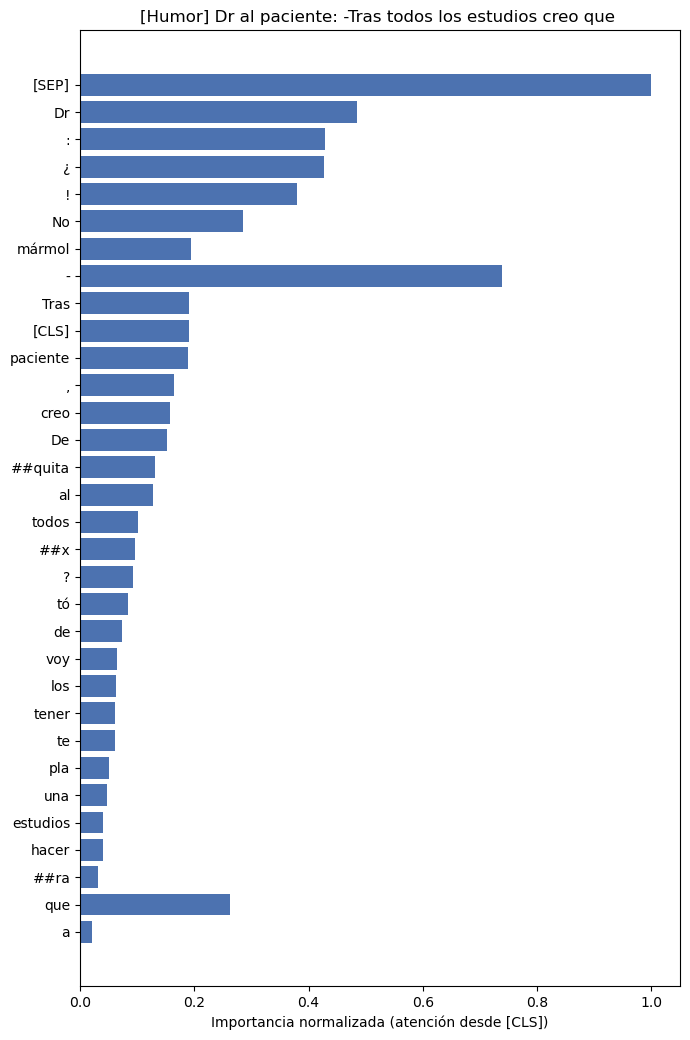


[Humor] Hablar no cuesta nada, excepto cuando se contrata a un abogado... #fb


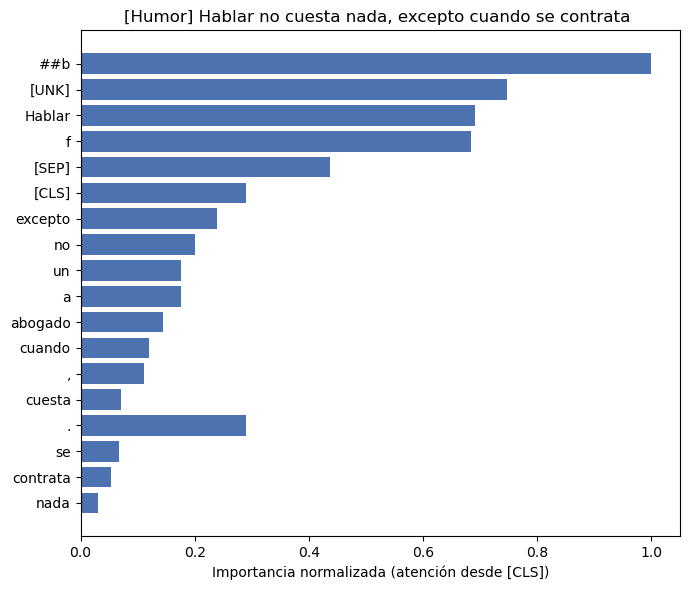


[Humor] #chiste Amor Te Voy Hacer Un Castillo Para Hacerte El Amor Como Una Princesa -Mejor Me Haces Un Manicomio Y Pichamos Como Locos! #chistes RT


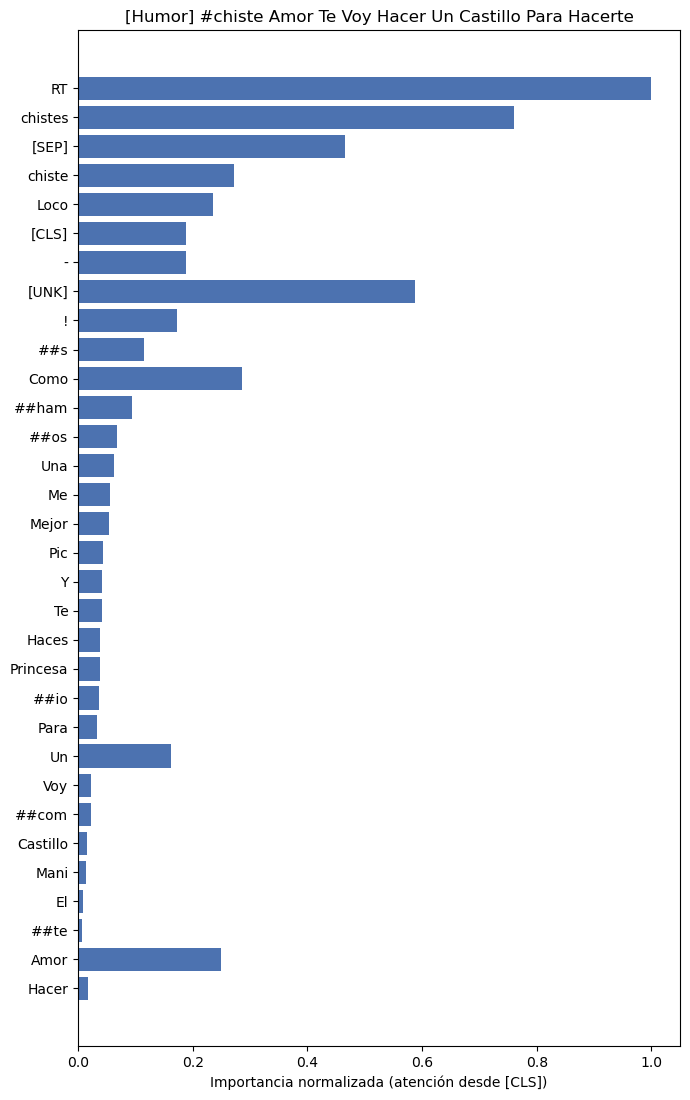


[No humor] No me soporten, sólo no me hablen.


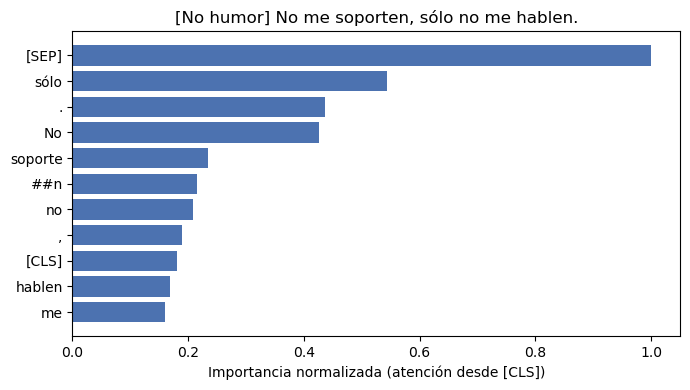


[No humor] Q áun en Guaynabo estan sin agua!???????????????


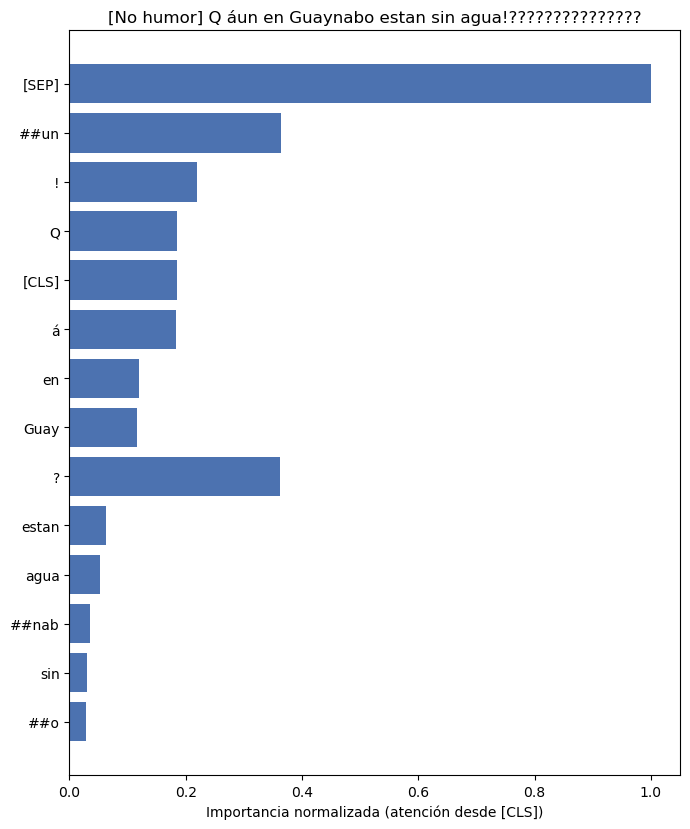


[No humor] Porque Zaninni está preso en una causa que aún con condena, no le correspondería estar en prisión e #21FYoMarcho


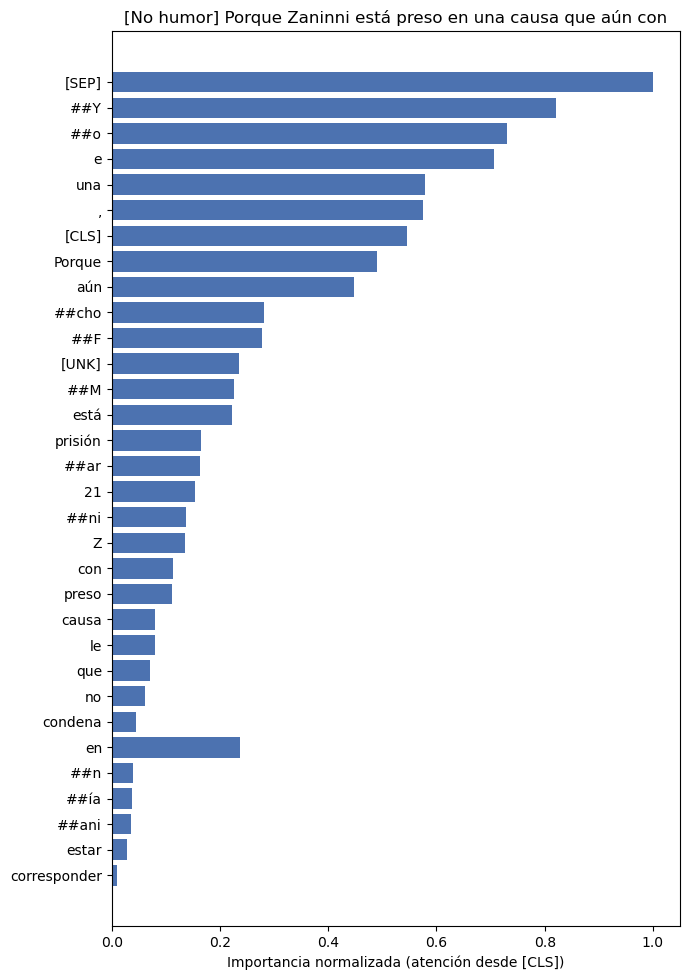

In [23]:
os.makedirs('results/lora/attention', exist_ok=True)

for i, (_, row) in enumerate(ejemplos.iterrows()):
    text = row[data_config.text_col]
    label = 'Humor' if row[data_config.label_col] == 1 else 'No humor'

    tokens, attentions = get_attention(text, tokenizer, model, data_config, device)
    importance = get_cls_importance(attentions, layer=-1)

    print(f"\n[{label}] {text}")
    fig = plot_token_importance(tokens, importance, title=f'[{label}] {text[:50]}')
    fig.savefig(f'results/lora/attention/token_importance_{i}.png', dpi=150)

## 6. Heatmap de atención (capa final, una cabeza)
Para uno o dos ejemplos puntuales, ver la matriz completa token-a-token.

In [24]:
def plot_attention_heatmap(tokens, attentions, layer=-1, head=0, title=''):
    attn = attentions[layer][head].numpy()  # [seq_len, seq_len]

    fig, ax = plt.subplots(figsize=(max(6, len(tokens)*0.5), max(5, len(tokens)*0.5)))
    im = ax.imshow(attn, cmap='viridis')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()
    return fig

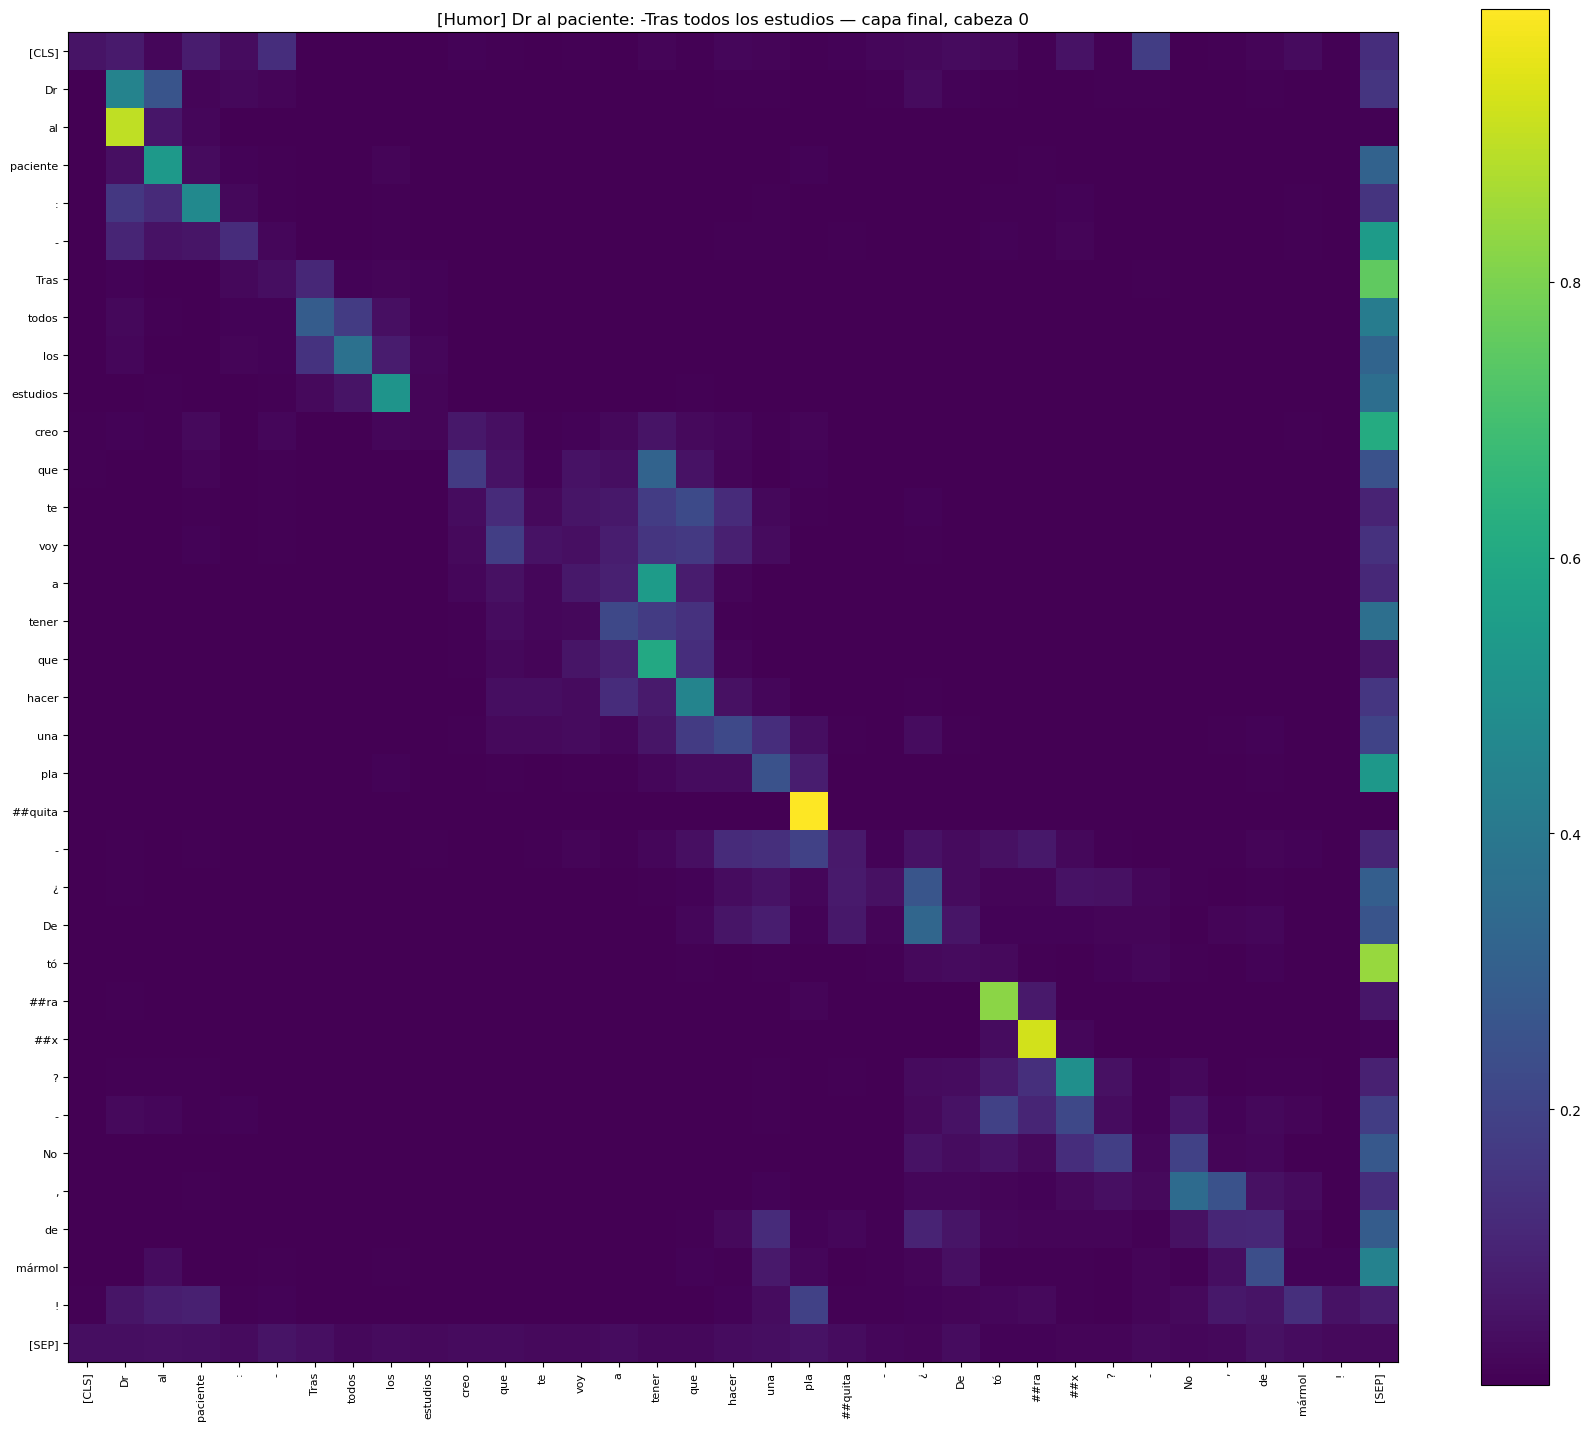

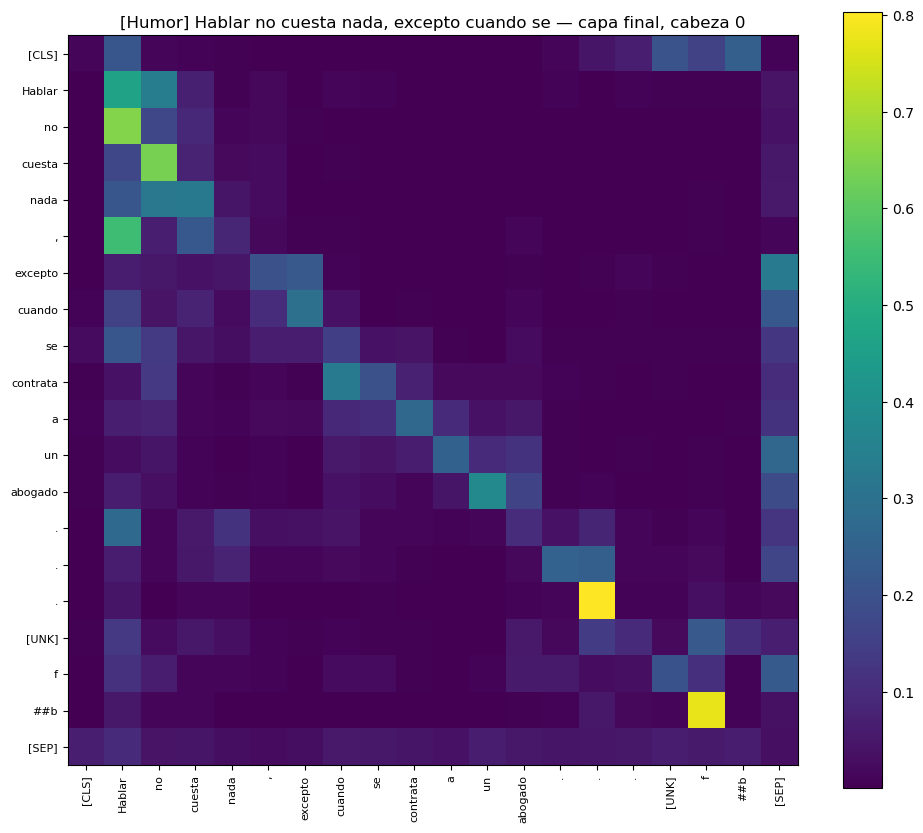

In [25]:
# Elegir un par de ejemplos representativos para el heatmap completo
for i, (_, row) in enumerate(ejemplos.head(2).iterrows()):
    text = row[data_config.text_col]
    label = 'Humor' if row[data_config.label_col] == 1 else 'No humor'

    tokens, attentions = get_attention(text, tokenizer, model, data_config, device)
    fig = plot_attention_heatmap(tokens, attentions, layer=-1, head=0, title=f'[{label}] {text[:40]} — capa final, cabeza 0')
    fig.savefig(f'results/lora/attention/heatmap_{i}.png', dpi=150)

In [ ]:
import shutil
from google.colab import files

shutil.make_archive('attention_results', 'zip', 'results/lora/attention')
files.download('attention_results.zip')